# 🧪 Uczenie Nadzorowane - Sieci Neuronowe (ANN): Laboratorium

**Wymagania wstępne:** zapoznaj się z notebookiem demonstracyjnym przed przystąpieniem do zadań.

---

## 📌 Zasady

- Pracujesz na **własnym zbiorze danych** (zdyskretyzowanym, wybranym na pierwszych zajęciach)
- Klasyfikacja zawsze odbywa się na **wszystkich cechach** zbioru
- Używaj **`Pipeline(StandardScaler + MLPClassifier)`** - normalizacja musi być wewnątrz CV

---

## ⚙️ Import bibliotek i wczytanie danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, ShuffleSplit,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('✅ Biblioteki załadowane')

✅ Biblioteki załadowane


In [2]:
# TODO: wczytaj własny zbiór danych
# df = pd.read_csv('...')
# FEATURES = [...]   # lista kolumn z cechami
# TARGET   = '...'   # nazwa kolumny decyzyjnej

# ──────────────────────────────────────────────────────────────────────
# ⚠️  WAŻNE: sprawdź typy kolumn PRZED podziałem na X i y
# print(df.dtypes)
# print(df.nunique())
#
# Jeśli masz kolumny kategoryczne, zakoduj je przed przekazaniem do MLP:
#
#   from sklearn.compose import ColumnTransformer
#   from sklearn.preprocessing import OneHotEncoder
#
#   num_cols = [...]   # kolumny liczbowe
#   cat_cols = [...]   # kolumny kategoryczne
#
#   preprocessor = ColumnTransformer([
#       ('num', StandardScaler(),                       num_cols),
#       ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
#   ])
#   pipe = Pipeline([('prep', preprocessor), ('mlp', MLPClassifier(...))])
# ──────────────────────────────────────────────────────────────────────

# X = df[FEATURES].values
# y = df[TARGET].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
# )

# print(f'Zbiór treningowy: {X_train.shape[0]} próbek')
# print(f'Zbiór testowy:    {X_test.shape[0]} próbek')
# print(f'Klasy: {sorted(np.unique(y))}')

In [4]:
df = pd.read_csv("data_discretized.csv")

FEATURES = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
TARGET = 'UNS'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(df.head())
print(df.shape)
print(df[TARGET].value_counts())

   STG  SCG  STR  LPR  PEG       UNS
0  0.0  0.0  0.0  0.0  0.0  Very Low
1  0.0  0.0  0.0  0.0  3.0      High
2  0.0  0.0  0.0  1.0  1.0       Low
3  0.0  0.0  0.0  3.0  1.0    Middle
4  0.0  0.0  0.0  3.0  0.0       Low
(403, 6)
UNS
Low         129
Middle      122
High        102
Very Low     50
Name: count, dtype: int64


---
# Zadanie 1 - Dobór architektury sieci i funkcji aktywacji

Twoim celem jest znalezienie optymalnej architektury MLP przy użyciu MCCV.

**Wymagania:**

1. Przetestuj przynajmniej **6 architektur** (różna liczba warstw i neuronów), np.:
   - 1 warstwa: `(32,)`, `(64,)`, `(128,)`
   - 2 warstwy: `(64, 32)`, `(128, 64)`
   - 3 warstwy: `(128, 64, 32)`
2. Użyj **MCCV** (ShuffleSplit, 30 iteracji, test=30%) jako metody walidacji
3. Używaj **`Pipeline(StandardScaler + MLPClassifier)`** - standaryzacja musi być wewnątrz CV
4. Przetestuj **wszystkie trzy funkcje aktywacji**: `relu`, `tanh`, `logistic`
5. Dla każdej kombinacji wypisz: architekturę, aktywację, średnią accuracy i odchylenie standardowe
6. Narysuj wykres słupkowy porównujący najlepszy wynik dla każdej architektury

> 💡 Wskazówka: możesz zagnieździć dwie pętle - jedna po architekturach, druga po aktywacjach.  
> Ustaw `max_iter=500` żeby dać modelowi czas na zbieżność.

In [5]:
architectures = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (128, 64),
    (128, 64, 32)
]

activations = ['relu', 'tanh', 'logistic']

mccv = ShuffleSplit(
    n_splits=30,
    test_size=0.30,
    random_state=RANDOM_STATE
)

results = []

for arch in architectures:
    for activation in activations:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=arch,
                activation=activation,
                max_iter=500,
                random_state=RANDOM_STATE
            ))
        ])

        scores = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=mccv,
            scoring='accuracy'
        )

        results.append({
            'architektura': arch,
            'aktywacja': activation,
            'accuracy_mean': scores.mean(),
            'accuracy_std': scores.std()
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='accuracy_mean', ascending=False)

display(results_df)

best_task1 = results_df.iloc[0]
print("Najlepszy model z Zadania 1:")
print(best_task1)

,architektura,aktywacja,accuracy_mean,accuracy_std
6,"(128,)",relu,0.800784,0.034492
14,"(128, 64)",logistic,0.800784,0.041753
10,"(64, 32)",tanh,0.800392,0.041703
9,"(64, 32)",relu,0.794510,0.037046
4,"(64,)",tanh,0.793725,0.036921
3,"(64,)",relu,0.791765,0.038800
7,"(128,)",tanh,0.791373,0.042520
1,"(32,)",tanh,0.791373,0.044117
12,"(128, 64)",relu,0.788235,0.035425
15,"(128, 64, 32)",relu,0.785098,0.037195


Najlepszy model z Zadania 1:
architektura       (128,)
aktywacja            relu
accuracy_mean    0.800784
accuracy_std     0.034492
Name: 6, dtype: object


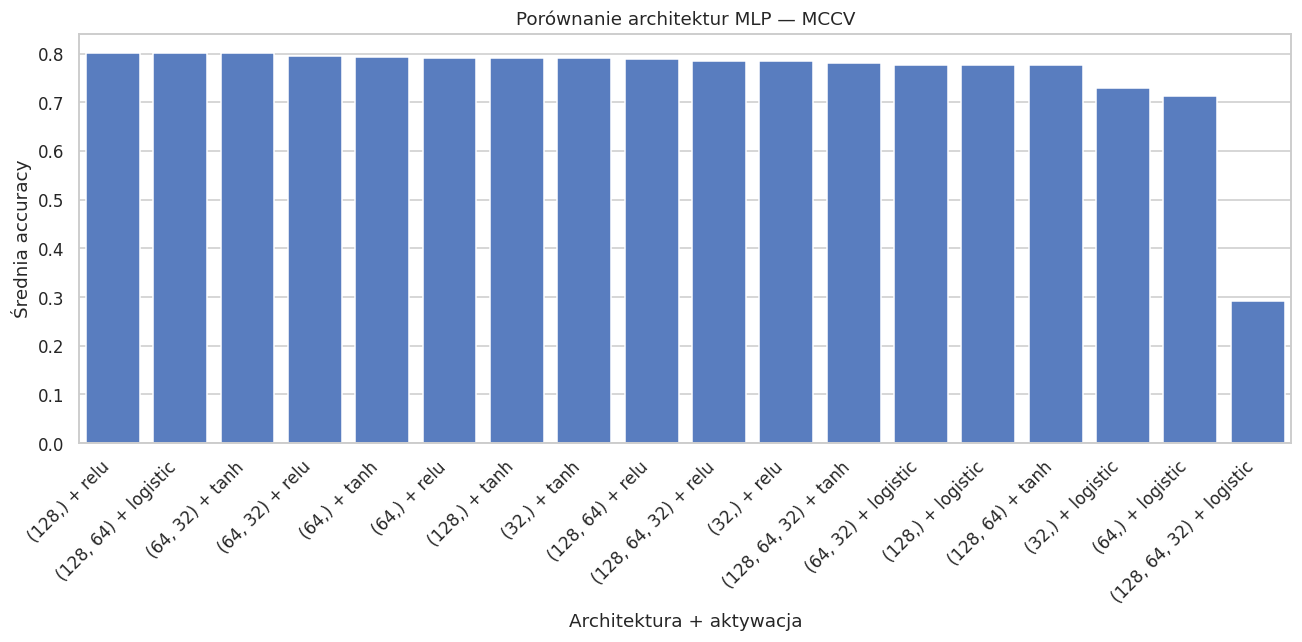

In [6]:
plt.figure(figsize=(12, 6))

plot_df = results_df.copy()
plot_df['model'] = plot_df['architektura'].astype(str) + " + " + plot_df['aktywacja']

sns.barplot(
    data=plot_df,
    x='model',
    y='accuracy_mean'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Średnia accuracy')
plt.xlabel('Architektura + aktywacja')
plt.title('Porównanie architektur MLP — MCCV')
plt.tight_layout()
plt.show()

**Komentarz do Zadania 1** - odpowiedz na pytania:

1. Która architektura i funkcja aktywacji dały najlepsze wyniki? Czy wynik jest zaskakujący?
2. Jak bardzo wyniki różnią się między architekturami? Czy głębsze sieci zawsze są lepsze?

1. Najlepszy wynik uzyskała architektura (128,) z funkcją aktywacji relu.
Średnia dokładność wyniosła 0.800784, a odchylenie standardowe 0.034492.

Wynik nie jest zaskakujący, ponieważ zbiór ma tylko 5 cech wejściowych, więc jedna warstwa ukryta z większą liczbą neuronów wystarczyła do dobrego odwzorowania zależności. Głębsza sieć nie była konieczna.

2. Najlepsze modele miały bardzo zbliżone wyniki: około 0.79–0.80. Różnice między najlepszymi konfiguracjami są niewielkie, np. (128,) + relu i (128, 64) + logistic uzyskały taki sam średni wynik 0.800784.

Głębsze sieci nie zawsze są lepsze. Przykładowo architektura (128, 64, 32) z logistic uzyskała bardzo niski wynik 0.290980, czyli znacznie gorszy niż prostsza sieć (128,) + relu.

---
# Zadanie 2 - GridSearchCV i regularyzacja

Dla najlepszej architektury z Zadania 1 przeprowadź pełne przeszukiwanie siatki parametrów
z uwzględnieniem regularyzacji L2.

**Wymagania:**

1. Wybierz architekturę z najlepszym wynikiem z Zadania 1 - uzasadnij wybór
2. Zdefiniuj siatkę parametrów (`param_grid`):
   - `hidden_layer_sizes` ∈ {wybrana + 2-3 zbliżone warianty}
   - `alpha` ∈ {1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0} (regularyzacja L2)
   - `activation` ∈ {`relu`, `tanh`}
3. Użyj `GridSearchCV` z `StratifiedKFold(n_splits=5)` jako CV wewnętrznym, w `Pipeline`
4. Wypisz: najlepsze parametry i najlepszą CV accuracy
5. Narysuj **heatmapę** wyników (alpha × architektura, dla najlepszej aktywacji)

> 💡 Wskazówka: pamiętaj o prefiksie `mlp__` dla parametrów w `param_grid`  
> (np. `'mlp__alpha': [...]`, `'mlp__hidden_layer_sizes': [...]`).

In [7]:
best_architecture = best_task1['architektura']

param_grid = {
    'mlp__hidden_layer_sizes': [
        best_architecture,
        (64,),
        (128,),
        (64, 32),
        (128, 64)
    ],
    'mlp__alpha': [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0],
    'mlp__activation': ['relu', 'tanh']
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=500,
        random_state=RANDOM_STATE
    ))
])

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Najlepsze parametry:")
print(grid.best_params_)

print("Najlepsza accuracy CV:")
print(grid.best_score_)

Najlepsze parametry:
{'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128,)}
Najlepsza accuracy CV:
0.8796365914786968


In [8]:
grid_results = pd.DataFrame(grid.cv_results_)

cols = [
    'param_mlp__hidden_layer_sizes',
    'param_mlp__activation',
    'param_mlp__alpha',
    'mean_test_score',
    'std_test_score',
    'mean_train_score'
]

display(grid_results[cols].sort_values(by='mean_test_score', ascending=False))

,param_mlp__hidden_layer_sizes,param_mlp__activation,param_mlp__alpha,mean_test_score,std_test_score,mean_train_score
17,"(128,)",relu,0.01000,0.879637,0.024994,0.921978
15,"(128,)",relu,0.01000,0.879637,0.024994,0.921978
0,"(128,)",relu,0.00001,0.872556,0.027308,0.922863
2,"(128,)",relu,0.00001,0.872556,0.027308,0.922863
10,"(128,)",relu,0.00100,0.872556,0.027308,0.921978
12,"(128,)",relu,0.00100,0.872556,0.027308,0.921978
7,"(128,)",relu,0.00010,0.872556,0.027308,0.922863
5,"(128,)",relu,0.00010,0.872556,0.027308,0.922863
20,"(128,)",relu,0.10000,0.868922,0.020443,0.917558
22,"(128,)",relu,0.10000,0.868922,0.020443,0.917558


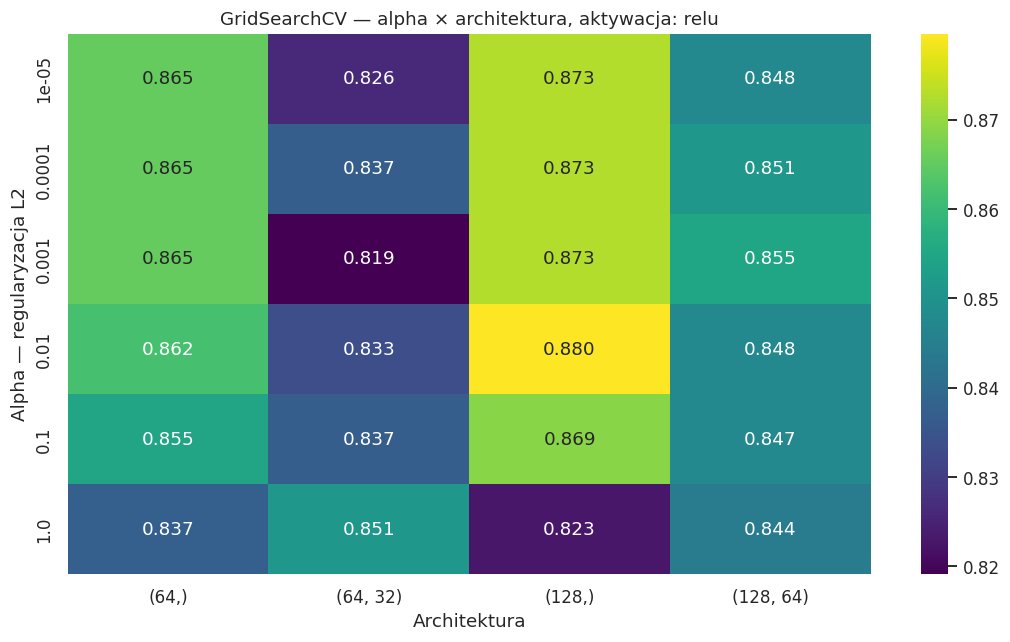

In [9]:
best_activation = grid.best_params_['mlp__activation']

heatmap_df = grid_results[
    grid_results['param_mlp__activation'] == best_activation
].copy()

pivot = heatmap_df.pivot_table(
    values='mean_test_score',
    index='param_mlp__alpha',
    columns='param_mlp__hidden_layer_sizes'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title(f"GridSearchCV — alpha × architektura, aktywacja: {best_activation}")
plt.xlabel("Architektura")
plt.ylabel("Alpha — regularyzacja L2")
plt.tight_layout()
plt.show()

**Komentarz do Zadania 2** - odpowiedz na pytania:

1. Czy wyniki GridSearchCV pokrywają się z ręcznym przeszukiwaniem z Zadania 1?
2. Co widać na heatmapie - jak `alpha` wpływa na wyniki? Przy jakiej wartości model się przeuczał / niedouczał?
3. Czy siatka parametrów była wystarczająco gęsta? Gdzie warto by ją zagęścić?

1. Tak, wyniki częściowo się pokrywają. W Zadaniu 1 najlepszy był model:

(128,) + relu

W GridSearchCV najlepszy model również miał:

hidden_layer_sizes = (128,)
activation = relu
alpha = 0.01

Czyli GridSearchCV potwierdził wybór architektury i aktywacji z Zadania 1, a dodatkowo dobrał najlepszą wartość regularyzacji L2.


2. Na heatmapie najlepszy wynik pojawia się dla:

architektura = (128,)
alpha = 0.01
accuracy = 0.880

Dla małych wartości alpha, takich jak 1e-5, 1e-4 i 1e-3, model też osiągał wysokie wyniki około 0.873, ale nie były one najlepsze. Oznacza to, że bez silniejszej regularyzacji model mógł być trochę bardziej podatny na przeuczenie.

Dla bardzo dużej wartości alpha = 1.0 wynik dla architektury (128,) spadł do około 0.823, więc model był wtedy zbyt mocno ograniczony i zaczynał się niedouczać.

3. Siatka była wystarczająca do znalezienia dobrego modelu, ponieważ wskazała konkretną najlepszą konfigurację. Warto byłoby ją jednak zagęścić wokół najlepszej wartości:

alpha = 0.01

Można sprawdzić dodatkowo np.:

0.003, 0.005, 0.007, 0.02, 0.03

Warto też dodać architektury bliskie (128,), np. (96,), (160,), (128, 32).

---
# Zadanie 3 - Krzywa uczenia, finalny model i ocena wyników

Na podstawie wyników z Zadań 1 i 2 wybierz najlepszy model i przeprowadź pełną ocenę.

**Wymagania:**

1. Wytrenuj finalny model z parametrami z Zadania 2 **z włączonym `early_stopping=True`**
2. Narysuj **krzywą uczenia** (loss vs epoka, train vs validation)
3. Zastosuj **Stratified K-Fold Cross-Validation** (5 foldów) i wypisz wyniki per fold oraz średnią
4. Oceń finalny model na zbiorze testowym - wyświetl **macierz pomyłek** i **raport klasyfikacji**

> 💡 Wskazówka: `early_stopping` i `loss_curve_` działają tylko na modelu trenowanym
> bezpośrednio (nie w CV). Wytrenuj model osobno po CV:
> ```python
> pipe.fit(X_train, y_train)
> mlp = pipe.named_steps['mlp']
> plt.plot(mlp.loss_curve_)
> ```

In [12]:
from sklearn.preprocessing import LabelEncoder

# kodowanie etykiet klas na liczby
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_enc = le.transform(y)

best_params = grid.best_params_

final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=best_params['mlp__hidden_layer_sizes'],
        activation=best_params['mlp__activation'],
        alpha=best_params['mlp__alpha'],
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=RANDOM_STATE
    ))
])

final_pipe.fit(X_train, y_train_enc)

y_pred_enc = final_pipe.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

print("Accuracy na zbiorze testowym:")
print(accuracy_score(y_test, y_pred))

print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))

Accuracy na zbiorze testowym:
0.5950413223140496

Raport klasyfikacji:
              precision    recall  f1-score   support

        High       0.81      0.73      0.77        30
         Low       0.51      0.77      0.61        39
      Middle       0.59      0.51      0.55        37
    Very Low       0.33      0.07      0.11        15

    accuracy                           0.60       121
   macro avg       0.56      0.52      0.51       121
weighted avg       0.59      0.60      0.57       121



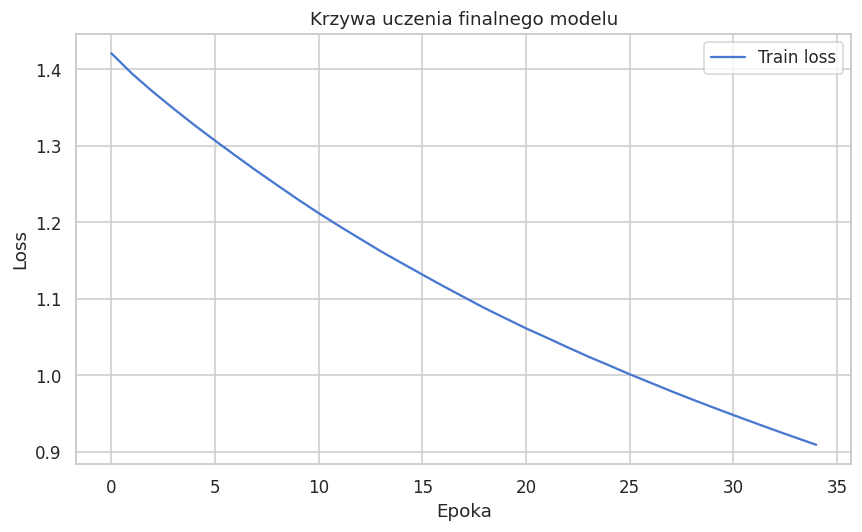

Liczba epok: 35


In [13]:
mlp = final_pipe.named_steps['mlp']

plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label='Train loss')

plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.title('Krzywa uczenia finalnego modelu')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Liczba epok:", mlp.n_iter_)

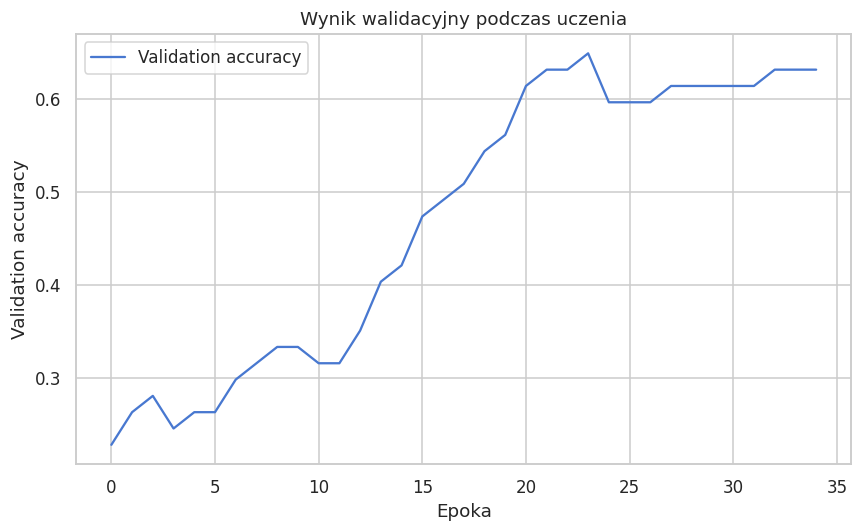

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.validation_scores_, label='Validation accuracy')

plt.xlabel('Epoka')
plt.ylabel('Validation accuracy')
plt.title('Wynik walidacyjny podczas uczenia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    final_pipe,
    X,
    y_enc,
    cv=skf,
    scoring='accuracy'
)

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"Średnia accuracy: {cv_scores.mean():.4f}")
print(f"Odchylenie standardowe: {cv_scores.std():.4f}")

Fold 1: 0.5926
Fold 2: 0.6914
Fold 3: 0.7531
Fold 4: 0.6500
Fold 5: 0.6500
Średnia accuracy: 0.6674
Odchylenie standardowe: 0.0531


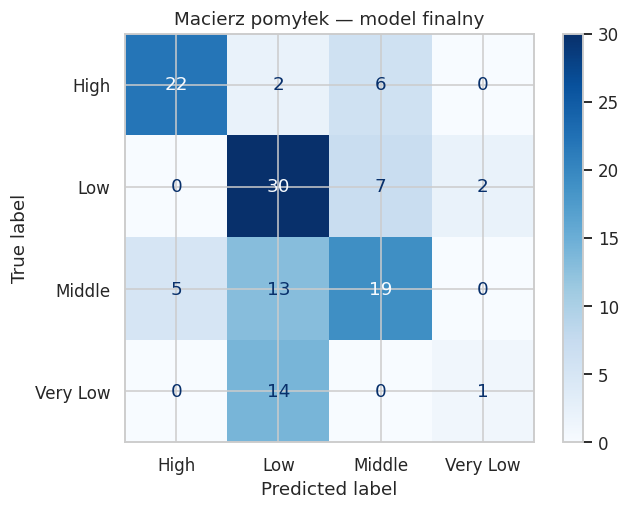

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues')
plt.title('Macierz pomyłek — model finalny')
plt.tight_layout()
plt.show()

**Komentarz do Zadania 3** - odpowiedz na pytania:

1. Co pokazuje krzywa uczenia? Czy model się przeuczał bez `early_stopping`?
   Po ilu epokach model osiągnął zbieżność?
2. Które klasy są najczęściej mylone?

1. Krzywa uczenia pokazuje, że wartość błędu treningowego systematycznie malała — z około 1.42 do około 0.91. To oznacza, że model uczył się poprawnie.

Krzywa walidacyjna rosła do około 0.64, a następnie ustabilizowała się. Model zatrzymał uczenie po 35 epokach, więc wtedy osiągnął zbieżność według mechanizmu early_stopping.

Nie można jednoznacznie powiedzieć, że model przeuczał się bez early_stopping, ponieważ w tym kodzie pokazany jest tylko model z early_stopping=True. Można jednak stwierdzić, że early_stopping ograniczył dalsze uczenie, gdy wynik walidacyjny przestał się poprawiać.

2. Na podstawie macierzy pomyłek najczęstsze błędy to:

Very Low → Low: 14 przypadków
Middle → Low: 13 przypadków
Low → Middle: 7 przypadków
High → Middle: 6 przypadków
Middle → High: 5 przypadków

Najgorzej rozpoznawana była klasa Very Low — tylko 1 z 15 przykładów został sklasyfikowany poprawnie. Większość przykładów tej klasy model przypisał do klasy Low.

Najlepiej rozpoznawane były klasy High i Low. Dla klasy High poprawnie sklasyfikowano 22 z 30 przykładów, a dla klasy Low 30 z 39 przykładów.